# IBM Employee Attrition Analysis — PCA Exploration

**Dataset:** IBM HR Analytics Employee Attrition (1,470 employees, 35 variables)  
**Tools:** Python · scikit-learn · pandas · seaborn · matplotlib

---

## Notebook Overview

This notebook applies Principal Component Analysis (PCA) to the attrition dataset as a supplementary exploratory step. The goal is to understand how variance is distributed across the feature set and whether dimensionality reduction helps with interpretation or class separation.

**Key questions explored:**
- How many components explain most of the variance in the dataset?
- How does standardization change the PCA solution?
- Do PCA-reduced features improve interpretability or class separation?

**Techniques covered:**
- PCA with and without feature standardization (`StandardScaler`)
- Explained variance ratio and scree plot analysis
- Inspection of component loadings
- Comparison of PCA-reduced features with the original feature space

**Project context:** PCA is treated here as an exploratory method, not as the core modeling pipeline.


# Principal Component Analysis (PCA)

This section explores PCA within the IBM attrition dataset. The purpose is to compare standardized and unstandardized solutions, inspect explained variance, and evaluate whether lower-dimensional representations help clarify structure in the feature space.


## Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import * # import all libraries under sklearn.metrics
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.metrics import *
plt.rc("font", size=14)

sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)





# ----
# See #1137: this allows compatibility for scikit-learn >= 0.24
import sklearn.utils
from sklearn.utils import safe_indexing
# except ImportError:
# from sklearn.utils import _safe_indexing

# Oversample and plot imbalanced dataset with ADASYN
from collections import Counter
from imblearn.over_sampling import ADASYN
from imblearn.over_sampling import SMOTE 
from imblearn.under_sampling import RandomUnderSampler
from matplotlib import pyplot
from numpy import where


%matplotlib inline


# 2 functions to print out metrics (written by us, not in sklearn)

# define a function for calculating the metric to be used later 
# takes in 2 inputs: Y_pred, Y_true
# and uses them to calculate metrics using functions in sklearn
def classification_metrics(Y_pred, Y_true):
    acc = accuracy_score(Y_true, Y_pred)
    precision = precision_score(Y_true, Y_pred)
    recall = recall_score(Y_true, Y_pred)
    f1score = f1_score(Y_true, Y_pred)
    auc = roc_auc_score(Y_true, y_pred)

    # the function's outputs are the 5 variables below
    return acc, precision, recall, f1score, auc

# define a function for printing the metrics using inputs: classifierName, Y_pred, Y_true
# e.g. inputs can be: 'Logistic Regression', y_pred, y_test
# inside the function, we do something with the inputs (e.g. run classification_metrics on the inputs)
# classification_metrics is antoher function we wrote above
def display_metrics(classifierName, Y_pred, Y_true):
    print ("______________________________________________")
    print ("Model: "+classifierName)
    acc, precision, recall, f1score, auc = classification_metrics(Y_pred, Y_true)
    # returns 5 vars: acc, precision, recall, f1score, auc
    # print them below
    print ("Accuracy: "+str(acc))
    print ("Precision: "+str(precision))
    print ("Recall: "+str(recall))
    print ("F1-score: "+str(f1score))
    print ("AUC: "+str(auc))
    print ("______________________________________________")
    print ("")






In [2]:
#import data 
df = pd.read_csv('HR_Attrition_IBM.csv')
df

df0 = df

# Pre - Processing

In [3]:
df.columns
df.shape # Columns and rows 
#1470 Rows X 35 Columns (variables)

(1470, 35)

## Missing Data


In [4]:
print(df.isnull()) # for each cell, print True/False (True = missing Data)

#df[df['player'].isnull()] # filtering that keeps rows with missing df.purpose for a variable

#df.dropna() # drop any row with ANY missing value for any feature in a row. 
df #NO MISSING DATA
print(len(df)) # NO MISSING DATA
print(df.shape)


# NO MISSING DATA



        Age  Attrition  BusinessTravel  DailyRate  Department  \
0     False      False           False      False       False   
1     False      False           False      False       False   
2     False      False           False      False       False   
3     False      False           False      False       False   
4     False      False           False      False       False   
5     False      False           False      False       False   
6     False      False           False      False       False   
7     False      False           False      False       False   
8     False      False           False      False       False   
9     False      False           False      False       False   
10    False      False           False      False       False   
11    False      False           False      False       False   
12    False      False           False      False       False   
13    False      False           False      False       False   
14    False      False   

In [5]:
#see number of rows of a dataframe or variable 
print(len(df)) # number of rows 
#print(len(df.***VARIABLE**)) # number of rows in a var (purpose)


1470


# Needless Data

In [6]:
# ---Removing Variable - "Over18" - all enteries are over 18--#
# df.Over18
df.Over18.unique()
df = df.drop('Over18', axis=1) # axis=1 indicates that 'new' is a column 



# ---Removing Variable - "StandardHours" - all enteries are 80---#
# df.StandardHours
df.StandardHours.unique()
df = df.drop('StandardHours', axis=1) # axis=1 indicates that 'new' is a column 



# [1470 rows x 33 columns]

In [7]:
# Converting Independent Variable DataTypes 


##Boolean/Categorical Data(attrition, Gender, Overtime)

##---OverTime----##
# df['OverTime'] = df.OverTime.astype('bool') #convert var 'date'to a date data type in our dataframe 'df'
df.loc[df["OverTime"] == "Yes", "OverTime"] = 1
df.loc[df["OverTime"] == "No", "OverTime"] = 0
##---Gender----##
# df['Gender'] = df.Gender.astype('bool') #convert var 'date'to a date data type in our dataframe 'df'
df.loc[df["Gender"] == "Male", "Gender"] = 1
df.loc[df["Gender"] == "Female", "Gender"] = 0


##Nominal Data/Ordinal Data/ Interval Data/ Ratio Data (PerformanceRating, etc.))

# print(df.info())
print(df)



#[1470 rows x 33 columns]



      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
5      32        No  Travel_Frequently       1005  Research & Development   
6      59        No      Travel_Rarely       1324  Research & Development   
7      30        No      Travel_Rarely       1358  Research & Development   
8      38        No  Travel_Frequently        216  Research & Development   
9      36        No      Travel_Rarely       1299  Research & Development   
10     35        No      Travel_Rarely        809  Research & Development   
11     29        No      Travel_Rarely        153  Research & Development   

### Assumption #1: The Response/Dependent Variable is Binary -- ## Data Type

In [8]:
# Converting Dependent Variable DataType

##Boolean/Categorical Data(attrition, Gender, Overtime)

##---Attrition----##
# df['Attrition'] = df.Attrition.astype('bool') #convert var 'date'to a date data type in our dataframe 'df'

# df.loc[df["Attrition"] == "Yes", "Attrition"] = 1
# df.loc[df["Attrition"] == "No", "Attrition"] = 0
df["Attrition"] = np.where(df["Attrition"] == "No", 0, 1)

##Nominal Data/Ordinal Data/ Interval Data/ Ratio Data (PerformanceRating, etc.))

# print(df.info())
# print(df)

df
#[1470 rows x 33 columns]


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,4,1,6,3,3,2,2,2,2
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,3,0,8,2,2,7,7,3,6
6,59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,4,1,3,12,3,2,1,0,0,0
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,4,2,1,1,2,3,1,0,0,0
8,38,0,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,4,2,0,10,2,3,9,7,1,8
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,3,2,2,17,3,2,7,7,7,7


In [9]:
df.Attrition.value_counts()



0    1233
1     237
Name: Attrition, dtype: int64

In [10]:
count_no_At = len(df[df['Attrition']==0])
count_At = len(df[df['Attrition']==1])
pct_of_no_At = count_no_At/(count_no_At+count_At)
print("percentage of no Attrition is", pct_of_no_At*100)
pct_of_At = count_At/(count_no_At+count_At)
print("percentage of Attrition", pct_of_At*100)

percentage of no Attrition is 83.87755102040816
percentage of Attrition 16.122448979591837


In [11]:
#check False/ No Attrition
1233/(1233+237)

# df.Attrition



0.8387755102040816

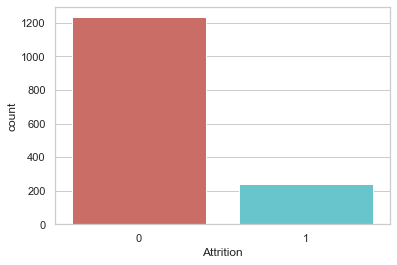

In [12]:
sns.countplot(x='Attrition', data=df, palette='hls')
plt.show()
# plt. savefig('count plot')

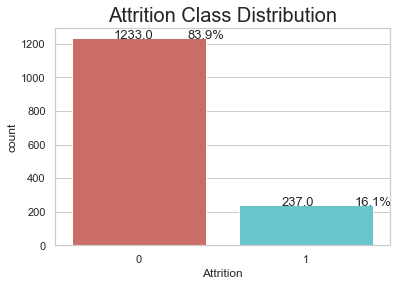

In [13]:
total = float(len(df))
ax = sns.countplot(x='Attrition', data=df, palette='hls')
plt.title('Attrition Class Distribution', fontsize=20)
for p in ax.patches:
    ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01), fontsize=13)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()
    y = p.get_height()
    ax.annotate(percentage, (x, y),ha='center', fontsize=13)
plt.show()



## Training a Decision Tree Model
- Use DecisionTreeClassifier in sklearn 
- Some paramters: 
    - criterion: The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “entropy” for the information gain.
    - max_depth: The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
    - min_samples_leaf: The minimum number of samples required to be at a leaf node. 
    - max_features: The number of features to consider when looking for the best split:
    - see all parameters in the documentation: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

# Decision Tree

### 1. Balancing the DV (Attrition) with our IV's

In [14]:
# Replicate original data so not to overwrite it 
df1 = df.copy()
dfs = df.copy()


df1 #[1470 rows × 33 columns]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,4,1,6,3,3,2,2,2,2
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,3,0,8,2,2,7,7,3,6
6,59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,4,1,3,12,3,2,1,0,0,0
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,4,2,1,1,2,3,1,0,0,0
8,38,0,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,4,2,0,10,2,3,9,7,1,8
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,3,2,2,17,3,2,7,7,7,7


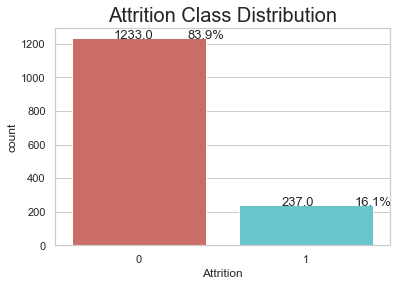

In [15]:
total = float(len(df1))
ax = sns.countplot(x='Attrition', data=df1, palette='hls')
plt.title('Attrition Class Distribution', fontsize=20)
for p in ax.patches:
    ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01), fontsize=13)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()
    y = p.get_height()
    ax.annotate(percentage, (x, y),ha='center', fontsize=13)
plt.show()

In [120]:
df1

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,4,1,6,3,3,2,2,2,2
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,3,0,8,2,2,7,7,3,6
6,59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,4,1,3,12,3,2,1,0,0,0
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,4,2,1,1,2,3,1,0,0,0
8,38,0,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,4,2,0,10,2,3,9,7,1,8
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,3,2,2,17,3,2,7,7,7,7


In [16]:
# create dummy variables for each country using function pd.get_dummies() for variable 'Country'
# add a prefix to names of dummies using 'prefix='Country'
# embed pd.get_dummies(ad_data2['Country'], prefix='Country') inside pd.conat()

# another way:
# countries = pd.get_dummies(ad_data2['Country'], prefix='Country')
# ad_data2 = pd.concat([ad_data2, countries],axis=1)


##-----BusinessTravel------###
df1 = pd.concat([df1, pd.get_dummies(df1['BusinessTravel'], prefix='BusinessTravel')],axis=1)
##-----Department------###
df1 = pd.concat([df1, pd.get_dummies(df1['Department'], prefix='Department')],axis=1)
##-----EducationField------###
df1 = pd.concat([df1, pd.get_dummies(df1['EducationField'], prefix='EducationField')],axis=1)
##-----JobRole------###
df1 = pd.concat([df1, pd.get_dummies(df1['JobRole'], prefix='JobRole')],axis=1)
##-----MaritalStatus------###
df1 = pd.concat([df1, pd.get_dummies(df1['MaritalStatus'], prefix='MaritalStatus')],axis=1)

In [17]:
### now drop the original 'country' column (you don't need it anymore)


##-----BusinessTravel------###
df1.drop(['BusinessTravel'],axis=1, inplace=True)
##-----Department------###
df1.drop(['Department'],axis=1, inplace=True)

##-----EducationField------###
df1.drop(['EducationField'],axis=1, inplace=True)

##-----JobRole------###
df1.drop(['JobRole'],axis=1, inplace=True)

##-----MaritalStatus------###
df1.drop(['MaritalStatus'],axis=1, inplace=True)


In [18]:
df1.info()
df1

# 1470 rows × 52 columns w/ Attrition(DV)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 52 columns):
Age                                  1470 non-null int64
Attrition                            1470 non-null int64
DailyRate                            1470 non-null int64
DistanceFromHome                     1470 non-null int64
Education                            1470 non-null int64
EmployeeCount                        1470 non-null int64
EmployeeNumber                       1470 non-null int64
EnvironmentSatisfaction              1470 non-null int64
Gender                               1470 non-null int64
HourlyRate                           1470 non-null int64
JobInvolvement                       1470 non-null int64
JobLevel                             1470 non-null int64
JobSatisfaction                      1470 non-null int64
MonthlyIncome                        1470 non-null int64
MonthlyRate                          1470 non-null int64
NumCompaniesWorked                   1

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,1,2,0,94,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,1,2,3,1,61,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,1,4,4,1,92,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,1,5,4,0,56,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,7,1,1,40,...,1,0,0,0,0,0,0,0,1,0
5,32,0,1005,2,2,1,8,4,1,79,...,1,0,0,0,0,0,0,0,0,1
6,59,0,1324,3,3,1,10,3,0,81,...,1,0,0,0,0,0,0,0,1,0
7,30,0,1358,24,1,1,11,4,1,67,...,1,0,0,0,0,0,0,1,0,0
8,38,0,216,23,3,1,12,4,1,44,...,0,0,1,0,0,0,0,0,0,1
9,36,0,1299,27,3,1,13,3,1,94,...,0,0,0,0,0,0,0,0,1,0


In [19]:
df1.columns
# 1470 rows × 52 columns



Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Healthcare

In [78]:
df1

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,1,2,0,94,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,1,2,3,1,61,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,1,4,4,1,92,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,1,5,4,0,56,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,7,1,1,40,...,1,0,0,0,0,0,0,0,1,0
5,32,0,1005,2,2,1,8,4,1,79,...,1,0,0,0,0,0,0,0,0,1
6,59,0,1324,3,3,1,10,3,0,81,...,1,0,0,0,0,0,0,0,1,0
7,30,0,1358,24,1,1,11,4,1,67,...,1,0,0,0,0,0,0,1,0,0
8,38,0,216,23,3,1,12,4,1,44,...,0,0,1,0,0,0,0,0,0,1
9,36,0,1299,27,3,1,13,3,1,94,...,0,0,0,0,0,0,0,0,1,0


In [20]:
# Create a list of predictor (x) variables: just Age
predictors1 = ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
               'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Healthcare Representative', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Research Scientist', 'JobRole_Sales Executive',
       'JobRole_Sales Representative', 'MaritalStatus_Divorced',
       'MaritalStatus_Married', 'MaritalStatus_Single']

# Create another list of predictor variables: Age, Country dummies (without the first country dummy) 
# [i for i in ad_data2.columns if i.startswith('Country')]: chooses all items in ad_data2.columns (var names)
# which start with 'Country'
# [i for i in ad_data2.columns if i.startswith('Country')][1:] -> add all countries but the first one (drop country at index 0)


###########predictors2 = ['Age']+[i for i in df1.columns if i.startswith('BusinessTravel')][1:]+[i for i in df1.columns if i.startswith('Department')][1:]+[i for i in df1.columns if i.startswith('EducationField')][1:]+[i for i in df1.columns if i.startswith('JobRole')][1:]+[i for i in df1.columns if i.startswith('MaritalStatus')][1:]


##-----BusinessTravel------###
##-----Department------###
##-----EducationField------###
##-----JobRole------###
##-----MaritalStatus------###




In [21]:
# create dataframes for X (using Age only) and y variables 
X = df1[predictors1] # choose predictors1
y = df1['Attrition'] # choose target var

# see list of X variables 
# X.columns is the list of var names
# [i for i in X.columns]: choose all the items in X.columns (var names in X) in list
print('X variables:\n', [i for i in X.columns])


X variables:
 ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRo

### Unbalanced DV: Over-Sampling with SMOTE

SMOTE: Synthetic Minority Over sampling Technique (SMOTE) algorithm applies KNN approach where it selects K nearest neighbors, joins them and creates the synthetic samples in the space. The algorithm takes the feature vectors and its nearest neighbors, computes the distance between these vectors. The difference is multiplied by random number between (0, 1) and it is added back to feature. SMOTE algorithm is a pioneer algorithm and many other algorithms are derived from SMOTE.


In [42]:
# extract new x-vars after dimensionality reduction
X = df1[predictors1]
y = df1['Attrition']

# X = [1470 rows × 51 columns/IVs]
# y = [1470 rows × 1 column/DV]

In [41]:
# X
# y

# X = [1470 rows × 51 columns/IVs]
# y = [1470 rows × 1 column/DV]

0       1
1       0
2       1
3       0
4       0
5       0
6       0
7       0
8       0
9       0
10      0
11      0
12      0
13      0
14      1
15      0
16      0
17      0
18      0
19      0
20      0
21      1
22      0
23      0
24      1
25      0
26      1
27      0
28      0
29      0
       ..
1440    0
1441    0
1442    1
1443    0
1444    1
1445    0
1446    0
1447    0
1448    0
1449    0
1450    0
1451    0
1452    1
1453    0
1454    0
1455    0
1456    0
1457    0
1458    0
1459    0
1460    0
1461    1
1462    0
1463    0
1464    0
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

In [43]:
sm = SMOTE(random_state=101)
X_res, y_res = sm.fit_resample(X, y)

In [44]:
# split data into train/test data
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state = 101)

model = DecisionTreeClassifier(criterion='entropy', random_state=101, max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

confusion_matrix_results = confusion_matrix(y_pred, y_test)

display_metrics('SMOTE - Decision Tree Classifier', y_pred, y_test)

______________________________________________
Model: Decision Tree Classifier
Accuracy: 0.7959459459459459
Precision: 0.7994269340974212
Recall: 0.775
F1-score: 0.7870239774330042
AUC: 0.7953947368421052
______________________________________________



In [45]:
SMOTElabels = pd.DataFrame(y_res) # label is the value of the target var
SMOTEfeatures = pd.DataFrame (X_res)

In [65]:
SMOTEdata = pd.concat([SMOTElabels, SMOTEfeatures], axis=1)
SMOTEdata

print(isinstance(SMOTEdata, pd.DataFrame))

SMOTEdata.to_csv('HR_Attrition_IBM.csv')


# [2466 rows × 52 columns]



True


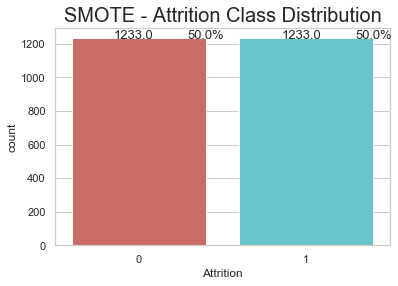

In [47]:
total = float(len(SMOTEdata))
ax = sns.countplot(x='Attrition', data=SMOTEdata, palette='hls')
plt.title('SMOTE - Attrition Class Distribution', fontsize=20)
for p in ax.patches:
    ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01), fontsize=13)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()
    y = p.get_height()
    ax.annotate(percentage, (x, y),ha='center', fontsize=13)
plt.show()

### Unbalanced DV: Over-Sampling with ADASYN

ADAptive SYNthetic (ADASYN) is based on the idea of adaptively generating minority data samples according to their distributions using K nearest neighbor. The algorithm adaptively updates the distribution and there are no assumptions made for the underlying distribution of the data.  The algorithm uses Euclidean distance for KNN Algorithm. The key difference between ADASYN and SMOTE is that the former uses a density distribution, as a criterion to automatically decide the number of synthetic samples that must be generated for each minority sample by adaptively changing the weights of the different minority samples to compensate for the skewed distributions. The latter generates the same number of synthetic samples for each original minority sample.

In [49]:
# extract new x-vars after dimensionality reduction
X = df1[predictors1]
y = df1['Attrition']

# X = [1470 rows × 51 columns/IVs]
# y = [1470 rows × 1 column/DV]

In [50]:
ada = ADASYN(random_state=101)
X_res, y_res = ada.fit_resample(X, y)


In [51]:
# split data into train/test data
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state = 101)

model = DecisionTreeClassifier(criterion='entropy', random_state=101, max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

confusion_matrix_results = confusion_matrix(y_pred, y_test)

display_metrics('ADASYN - Decision Tree Classifier', y_pred, y_test)

______________________________________________
Model: Decision Tree Classifier
Accuracy: 0.7894736842105263
Precision: 0.7875
Recall: 0.75
F1-score: 0.7682926829268292
AUC: 0.7869170984455959
______________________________________________



In [52]:
ADAlabels = pd.DataFrame(y_res) # label is the value of the target var
ADAfeatures = pd.DataFrame (X_res)

In [53]:
ADAdata = pd.concat([ADAlabels, ADAfeatures], axis=1)
ADAdata

# [2406 rows × 52 columns]



,Attrition,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,1,41,1102,1,2,1,1,2,0,94,...,0,0,0,0,0,1,0,0,0,1
1,0,49,279,8,1,1,2,3,1,61,...,0,0,0,0,1,0,0,0,1,0
2,1,37,1373,2,2,1,4,4,1,92,...,1,0,0,0,0,0,0,0,0,1
3,0,33,1392,3,4,1,5,4,0,56,...,0,0,0,0,1,0,0,0,1,0
4,0,27,591,2,1,1,7,1,1,40,...,1,0,0,0,0,0,0,0,1,0
5,0,32,1005,2,2,1,8,4,1,79,...,1,0,0,0,0,0,0,0,0,1
6,0,59,1324,3,3,1,10,3,0,81,...,1,0,0,0,0,0,0,0,1,0
7,0,30,1358,24,1,1,11,4,1,67,...,1,0,0,0,0,0,0,1,0,0
8,0,38,216,23,3,1,12,4,1,44,...,0,0,1,0,0,0,0,0,0,1
9,0,36,1299,27,3,1,13,3,1,94,...,0,0,0,0,0,0,0,0,1,0


In [66]:
ADAdata = pd.concat([ADAlabels, ADAfeatures], axis=1)
ADAdata

print(isinstance(ADAdata, pd.DataFrame))

ADAdata.to_csv('HR_Attrition_IBM.csv')


# [2406 rows × 52 columns]



True


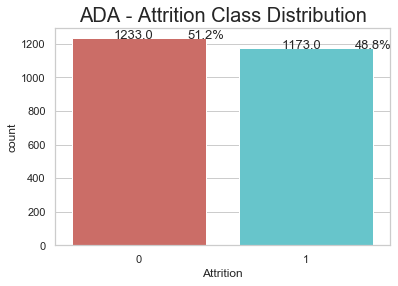

In [55]:
total = float(len(ADAdata))
ax = sns.countplot(x='Attrition', data=ADAdata, palette='hls')
plt.title('ADASYN - Attrition Class Distribution', fontsize=20)
for p in ax.patches:
    ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01), fontsize=13)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()
    y = p.get_height()
    ax.annotate(percentage, (x, y),ha='center', fontsize=13)
plt.show()

# Logistic Regressoin 

In [16]:
# Replicate original data so not to overwrite it 
df1 = df.copy()
dfs = df.copy()



In [395]:
# create dummy variables for each country using function pd.get_dummies() for variable 'Country'
# add a prefix to names of dummies using 'prefix='Country'
# embed pd.get_dummies(ad_data2['Country'], prefix='Country') inside pd.conat()

# another way:
# countries = pd.get_dummies(ad_data2['Country'], prefix='Country')
# ad_data2 = pd.concat([ad_data2, countries],axis=1)

##-----BusinessTravel------###
df1 = pd.concat([df1, pd.get_dummies(df1['BusinessTravel'], prefix='BusinessTravel')],axis=1)
##-----Department------###
df1 = pd.concat([df1, pd.get_dummies(df1['Department'], prefix='Department')],axis=1)
##-----EducationField------###
df1 = pd.concat([df1, pd.get_dummies(df1['EducationField'], prefix='EducationField')],axis=1)
##-----JobRole------###
df1 = pd.concat([df1, pd.get_dummies(df1['JobRole'], prefix='JobRole')],axis=1)
##-----MaritalStatus------###
df1 = pd.concat([df1, pd.get_dummies(df1['MaritalStatus'], prefix='MaritalStatus')],axis=1)



In [396]:
### now drop the original 'country' column (you don't need it anymore)


##-----BusinessTravel------###
df1.drop(['BusinessTravel'],axis=1, inplace=True)
##-----Department------###
df1.drop(['Department'],axis=1, inplace=True)

##-----EducationField------###
df1.drop(['EducationField'],axis=1, inplace=True)

##-----JobRole------###
df1.drop(['JobRole'],axis=1, inplace=True)

##-----MaritalStatus------###
df1.drop(['MaritalStatus'],axis=1, inplace=True)


In [397]:
df1.info()
df1

# 1470 rows × 52 columns



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 52 columns):
Age                                  1470 non-null int64
Attrition                            1470 non-null int64
DailyRate                            1470 non-null int64
DistanceFromHome                     1470 non-null int64
Education                            1470 non-null int64
EmployeeCount                        1470 non-null int64
EmployeeNumber                       1470 non-null int64
EnvironmentSatisfaction              1470 non-null int64
Gender                               1470 non-null int64
HourlyRate                           1470 non-null int64
JobInvolvement                       1470 non-null int64
JobLevel                             1470 non-null int64
JobSatisfaction                      1470 non-null int64
MonthlyIncome                        1470 non-null int64
MonthlyRate                          1470 non-null int64
NumCompaniesWorked                   1

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,1,2,0,94,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,1,2,3,1,61,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,1,4,4,1,92,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,1,5,4,0,56,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,7,1,1,40,...,1,0,0,0,0,0,0,0,1,0
5,32,0,1005,2,2,1,8,4,1,79,...,1,0,0,0,0,0,0,0,0,1
6,59,0,1324,3,3,1,10,3,0,81,...,1,0,0,0,0,0,0,0,1,0
7,30,0,1358,24,1,1,11,4,1,67,...,1,0,0,0,0,0,0,1,0,0
8,38,0,216,23,3,1,12,4,1,44,...,0,0,1,0,0,0,0,0,0,1
9,36,0,1299,27,3,1,13,3,1,94,...,0,0,0,0,0,0,0,0,1,0


In [398]:
df1.columns
# 1470 rows × 52 columns



Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Healthcare

In [130]:
# # create the dataset with labels (y-variable, the written number in this case) and features (64 x-variables)
# # label: digit
# # 64 pixels -> 64 x-variables (each var is a pixel, and the value represents the darkness)
# features = pd.DataFrame(df1.data)
# labels = pd.DataFrame(df1.target, columns={'label'}) # label is the value of the target var
# data = pd.concat([labels, features], axis=1)
# data


In [367]:
df1

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,1,2,0,94,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,1,2,3,1,61,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,1,4,4,1,92,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,1,5,4,0,56,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,7,1,1,40,...,1,0,0,0,0,0,0,0,1,0
5,32,0,1005,2,2,1,8,4,1,79,...,1,0,0,0,0,0,0,0,0,1
6,59,0,1324,3,3,1,10,3,0,81,...,1,0,0,0,0,0,0,0,1,0
7,30,0,1358,24,1,1,11,4,1,67,...,1,0,0,0,0,0,0,1,0,0
8,38,0,216,23,3,1,12,4,1,44,...,0,0,1,0,0,0,0,0,0,1
9,36,0,1299,27,3,1,13,3,1,94,...,0,0,0,0,0,0,0,0,1,0


In [111]:
# Create a list of predictor (x) variables: just Age
predictors1 = ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
               'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Healthcare Representative', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Research Scientist', 'JobRole_Sales Executive',
       'JobRole_Sales Representative', 'MaritalStatus_Divorced',
       'MaritalStatus_Married', 'MaritalStatus_Single']

# Create another list of predictor variables: Age, Country dummies (without the first country dummy) 
# [i for i in ad_data2.columns if i.startswith('Country')]: chooses all items in ad_data2.columns (var names)
# which start with 'Country'
# [i for i in ad_data2.columns if i.startswith('Country')][1:] -> add all countries but the first one (drop country at index 0)


###########predictors2 = ['Age']+[i for i in df1.columns if i.startswith('BusinessTravel')][1:]+[i for i in df1.columns if i.startswith('Department')][1:]+[i for i in df1.columns if i.startswith('EducationField')][1:]+[i for i in df1.columns if i.startswith('JobRole')][1:]+[i for i in df1.columns if i.startswith('MaritalStatus')][1:]


##-----BusinessTravel------###
##-----Department------###
##-----EducationField------###
##-----JobRole------###
##-----MaritalStatus------###




In [127]:
# create dataframes for X (using Age only) and y variables 
features = df1[predictors1] # choose predictors1
y = df1['Attrition'] # choose target var

# see list of X variables 
# X.columns is the list of var names
# [i for i in X.columns]: choose all the items in X.columns (var names in X) in list
print('X variables:\n', [i for i in features.columns])


X variables:
 ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRo

In [128]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 51 columns):
Age                                  1470 non-null int64
DailyRate                            1470 non-null int64
DistanceFromHome                     1470 non-null int64
Education                            1470 non-null int64
EmployeeCount                        1470 non-null int64
EmployeeNumber                       1470 non-null int64
EnvironmentSatisfaction              1470 non-null int64
Gender                               1470 non-null int64
HourlyRate                           1470 non-null int64
JobInvolvement                       1470 non-null int64
JobLevel                             1470 non-null int64
JobSatisfaction                      1470 non-null int64
MonthlyIncome                        1470 non-null int64
MonthlyRate                          1470 non-null int64
NumCompaniesWorked                   1470 non-null int64
OverTime                             1

In [129]:
labels = pd.DataFrame(y) # label is the value of the target var

In [130]:
data = pd.concat([labels, features], axis=1)
data

# [1470 rows × 52 columns]



,Attrition,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,1,41,1102,1,2,1,1,2,0,94,...,0,0,0,0,0,1,0,0,0,1
1,0,49,279,8,1,1,2,3,1,61,...,0,0,0,0,1,0,0,0,1,0
2,1,37,1373,2,2,1,4,4,1,92,...,1,0,0,0,0,0,0,0,0,1
3,0,33,1392,3,4,1,5,4,0,56,...,0,0,0,0,1,0,0,0,1,0
4,0,27,591,2,1,1,7,1,1,40,...,1,0,0,0,0,0,0,0,1,0
5,0,32,1005,2,2,1,8,4,1,79,...,1,0,0,0,0,0,0,0,0,1
6,0,59,1324,3,3,1,10,3,0,81,...,1,0,0,0,0,0,0,0,1,0
7,0,30,1358,24,1,1,11,4,1,67,...,1,0,0,0,0,0,0,1,0,0
8,0,38,216,23,3,1,12,4,1,44,...,0,0,1,0,0,0,0,0,0,1
9,0,36,1299,27,3,1,13,3,1,94,...,0,0,0,0,0,0,0,0,1,0


# PCA

## PCA: Get cumulative explained variance for a particular number of components


In [131]:
# extract x and y vars 
X = data.iloc[:,1:] # all rows, columns 1 and onwards
y = data.iloc[:,0] # all rows, column 0

# define and fit PCA, set n_components (e.g. 10)
pca = PCA(n_components = 3, random_state = 101).fit(X) 

# pca.explained_variance_ratio_ gives var explained by each PC
# use np.sum() to add it up to get cumulative var explained
np.sum(pca.explained_variance_ratio_)


0.9977841059513041

## PCA: Choose the number of components


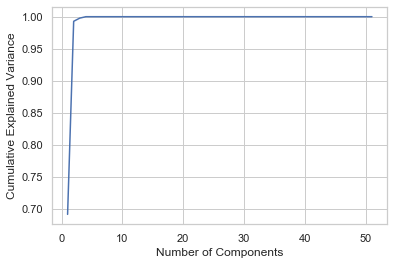

In [132]:
# extract x and y vars 
X = data.iloc[:,1:] # all rows, columns 1 and onwards
y = data.iloc[:,0] # all rows, column 0

# if n_components is not set, then PCA will run for every possible # of components (1 to 64 here)
pca = PCA(random_state = 101).fit(X) 

components = list(range(1, X.shape[1]+1)) # get a list of # of components
cumulative_var = np.cumsum(pca.explained_variance_ratio_) # use np.cumsum function to calculate cumulative var by # of components

plt.plot(components, cumulative_var)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance');


## PCA: Reduce dimensionality and calculate new values based on principal components


In [133]:
# extract x and y vars 
X = data.iloc[:,1:] # all rows, columns 1 and onwards
y = data.iloc[:,0] # all rows, column 0

pca = PCA(n_components = 3, random_state = 101) # choose # of principal components (e.g. 2)

# fit PCA to data 
pca.fit(X) 

# transform x-vars using PCs -> reduce 64 x-vars to 2 
projected = pca.transform(X) 

# format the results into a dataframe
projected_variables = pd.DataFrame(projected)
data2 = pd.concat([labels, projected_variables], axis=1)
data2.head()


,Attrition,0,1,2
0,1,5139.143996,-718.086066,-1047.617986
1,0,10528.865118,-1802.653394,-1004.883326
2,1,-12089.425912,-3920.145609,-1048.000372
3,0,8689.622036,-3949.517561,-1072.175347
4,0,2192.360871,-3125.191264,-1012.117636


In [134]:
print(data.iloc[:,1:].shape)
print(data2.iloc[:,1:].shape) 

(1470, 51)
(1470, 3)


## Make predictions with PCA components

components: 1 , accuracy: 0.8367346938775511
components: 2 , accuracy: 0.8390022675736961
components: 3 , accuracy: 0.8412698412698413
components: 4 , accuracy: 0.8253968253968254
components: 5 , accuracy: 0.8253968253968254
components: 6 , accuracy: 0.8231292517006803
components: 7 , accuracy: 0.8095238095238095
components: 8 , accuracy: 0.8140589569160998
components: 9 , accuracy: 0.8140589569160998
components: 10 , accuracy: 0.8163265306122449
components: 11 , accuracy: 0.8095238095238095
components: 12 , accuracy: 0.8072562358276644
components: 13 , accuracy: 0.8095238095238095
components: 14 , accuracy: 0.8095238095238095
components: 15 , accuracy: 0.8117913832199547
components: 16 , accuracy: 0.8117913832199547
components: 17 , accuracy: 0.8276643990929705
components: 18 , accuracy: 0.8163265306122449
components: 19 , accuracy: 0.8072562358276644
components: 20 , accuracy: 0.7959183673469388
components: 21 , accuracy: 0.7891156462585034
components: 22 , accuracy: 0.78911564625850

Text(0.5, 1.0, 'Accuracy vs. # of Principal Components')

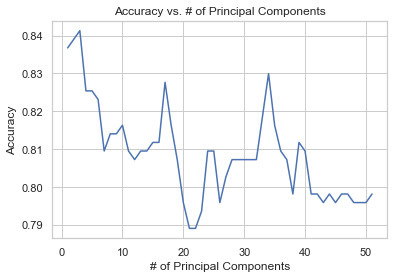

In [141]:
X = data.iloc[:,1:]
y = data.iloc[:,0]

accuracies = [] # compare accuracies for using diff # of components
components = list(range(1, X.shape[1]+1)) # a list of 1 to 64 

for i in range(1, X.shape[1]+1): # loop through 1 to 64 
    
    # define PCA
    pca = PCA(n_components = i, random_state = 101) 
    
    # fit PCA to data
    pca.fit(X)
    
    # transform x-vars using PCs -> reduce 64 x-vars to i x-vars
    projected = pca.transform(X)
    projected_variables = pd.DataFrame(projected)
    
    # new data with dimensionality reduction
    data2 = pd.concat([labels, projected_variables], axis=1)
    
    # extract new x-vars after dimensionality reduction
    X2 = data2.iloc[:,1:]
    y2 = data2.iloc[:,0]
    
    # split data into train/test data
    X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.3, random_state = 101, stratify=y2)
    
    # DT Model
    model =  DecisionTreeClassifier(criterion='entropy', random_state=101, max_depth=5)

    # fit the model
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)
    
    print('components:', i, ', accuracy:', acc)

plt.plot(components, accuracies)
plt.ylabel('Accuracy')
plt.xlabel('# of Principal Components')
plt.title('Accuracy vs. # of Principal Components')

# components: 3 , accuracy: 0.8412698412698413

In [144]:
# # print(X_train)
# y_train
# y_train = pd.DataFrame(y_train)
# print(y_train)
# isinstance(y_train, pd.DataFrame)


In [145]:
# le = LabelEncoder()

# le.fit(y_train)

# y_train = le.transform(y_train)
# y_test = le.transform(y_test)

# y_train
# y

In [146]:
# y_train['Attrition'].value_counts()

# # y_train.value_counts



## Training a Decision Tree Model
- Use DecisionTreeClassifier in sklearn 
- Some paramters: 
    - criterion: The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “entropy” for the information gain.
    - max_depth: The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
    - min_samples_leaf: The minimum number of samples required to be at a leaf node. 
    - max_features: The number of features to consider when looking for the best split:
    - see all parameters in the documentation: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

## Data Prep: Decision Tree

### 1. Unbalanced DV

In [71]:
# Replicate original data so not to overwrite it 
df1 = df.copy()
dfs = df.copy()


df1 #[1470 rows × 33 columns]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,4,1,6,3,3,2,2,2,2
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,3,0,8,2,2,7,7,3,6
6,59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,4,1,3,12,3,2,1,0,0,0
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,4,2,1,1,2,3,1,0,0,0
8,38,0,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,4,2,0,10,2,3,9,7,1,8
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,3,2,2,17,3,2,7,7,7,7


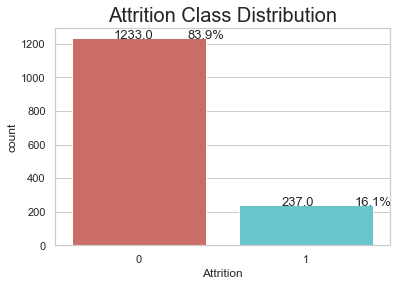

In [72]:
total = float(len(df1))
ax = sns.countplot(x='Attrition', data=df1, palette='hls')
plt.title('Attrition Class Distribution', fontsize=20)
for p in ax.patches:
    ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01), fontsize=13)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()
    y = p.get_height()
    ax.annotate(percentage, (x, y),ha='center', fontsize=13)
plt.show()

In [73]:
df1

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,4,1,6,3,3,2,2,2,2
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,3,0,8,2,2,7,7,3,6
6,59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,4,1,3,12,3,2,1,0,0,0
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,4,2,1,1,2,3,1,0,0,0
8,38,0,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,4,2,0,10,2,3,9,7,1,8
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,3,2,2,17,3,2,7,7,7,7


In [74]:
# create dummy variables for each country using function pd.get_dummies() for variable 'Country'
# add a prefix to names of dummies using 'prefix='Country'
# embed pd.get_dummies(ad_data2['Country'], prefix='Country') inside pd.conat()

# another way:
# countries = pd.get_dummies(ad_data2['Country'], prefix='Country')
# ad_data2 = pd.concat([ad_data2, countries],axis=1)


##-----BusinessTravel------###
df1 = pd.concat([df1, pd.get_dummies(df1['BusinessTravel'], prefix='BusinessTravel')],axis=1)
##-----Department------###
df1 = pd.concat([df1, pd.get_dummies(df1['Department'], prefix='Department')],axis=1)
##-----EducationField------###
df1 = pd.concat([df1, pd.get_dummies(df1['EducationField'], prefix='EducationField')],axis=1)
##-----JobRole------###
df1 = pd.concat([df1, pd.get_dummies(df1['JobRole'], prefix='JobRole')],axis=1)
##-----MaritalStatus------###
df1 = pd.concat([df1, pd.get_dummies(df1['MaritalStatus'], prefix='MaritalStatus')],axis=1)

In [75]:
### now drop the original 'country' column (you don't need it anymore)


##-----BusinessTravel------###
df1.drop(['BusinessTravel'],axis=1, inplace=True)
##-----Department------###
df1.drop(['Department'],axis=1, inplace=True)

##-----EducationField------###
df1.drop(['EducationField'],axis=1, inplace=True)

##-----JobRole------###
df1.drop(['JobRole'],axis=1, inplace=True)

##-----MaritalStatus------###
df1.drop(['MaritalStatus'],axis=1, inplace=True)


In [76]:
df1.info()
df1

# 1470 rows × 52 columns w/ Attrition(DV)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 52 columns):
Age                                  1470 non-null int64
Attrition                            1470 non-null int64
DailyRate                            1470 non-null int64
DistanceFromHome                     1470 non-null int64
Education                            1470 non-null int64
EmployeeCount                        1470 non-null int64
EmployeeNumber                       1470 non-null int64
EnvironmentSatisfaction              1470 non-null int64
Gender                               1470 non-null int64
HourlyRate                           1470 non-null int64
JobInvolvement                       1470 non-null int64
JobLevel                             1470 non-null int64
JobSatisfaction                      1470 non-null int64
MonthlyIncome                        1470 non-null int64
MonthlyRate                          1470 non-null int64
NumCompaniesWorked                   1

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,1,2,0,94,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,1,2,3,1,61,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,1,4,4,1,92,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,1,5,4,0,56,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,7,1,1,40,...,1,0,0,0,0,0,0,0,1,0
5,32,0,1005,2,2,1,8,4,1,79,...,1,0,0,0,0,0,0,0,0,1
6,59,0,1324,3,3,1,10,3,0,81,...,1,0,0,0,0,0,0,0,1,0
7,30,0,1358,24,1,1,11,4,1,67,...,1,0,0,0,0,0,0,1,0,0
8,38,0,216,23,3,1,12,4,1,44,...,0,0,1,0,0,0,0,0,0,1
9,36,0,1299,27,3,1,13,3,1,94,...,0,0,0,0,0,0,0,0,1,0


In [77]:
df1.columns
# 1470 rows × 52 columns



Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Healthcare

In [78]:
df1

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,1,2,0,94,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,1,2,3,1,61,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,1,4,4,1,92,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,1,5,4,0,56,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,7,1,1,40,...,1,0,0,0,0,0,0,0,1,0
5,32,0,1005,2,2,1,8,4,1,79,...,1,0,0,0,0,0,0,0,0,1
6,59,0,1324,3,3,1,10,3,0,81,...,1,0,0,0,0,0,0,0,1,0
7,30,0,1358,24,1,1,11,4,1,67,...,1,0,0,0,0,0,0,1,0,0
8,38,0,216,23,3,1,12,4,1,44,...,0,0,1,0,0,0,0,0,0,1
9,36,0,1299,27,3,1,13,3,1,94,...,0,0,0,0,0,0,0,0,1,0


In [79]:
# Create a list of predictor (x) variables: just Age
predictors1 = ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
               'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Healthcare Representative', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Research Scientist', 'JobRole_Sales Executive',
       'JobRole_Sales Representative', 'MaritalStatus_Divorced',
       'MaritalStatus_Married', 'MaritalStatus_Single']

# Create another list of predictor variables: Age, Country dummies (without the first country dummy) 
# [i for i in ad_data2.columns if i.startswith('Country')]: chooses all items in ad_data2.columns (var names)
# which start with 'Country'
# [i for i in ad_data2.columns if i.startswith('Country')][1:] -> add all countries but the first one (drop country at index 0)


###########predictors2 = ['Age']+[i for i in df1.columns if i.startswith('BusinessTravel')][1:]+[i for i in df1.columns if i.startswith('Department')][1:]+[i for i in df1.columns if i.startswith('EducationField')][1:]+[i for i in df1.columns if i.startswith('JobRole')][1:]+[i for i in df1.columns if i.startswith('MaritalStatus')][1:]


##-----BusinessTravel------###
##-----Department------###
##-----EducationField------###
##-----JobRole------###
##-----MaritalStatus------###




In [80]:
# create dataframes for X (using Age only) and y variables 
X = df1[predictors1] # choose predictors1
y = df1['Attrition'] # choose target var

# see list of X variables 
# X.columns is the list of var names
# [i for i in X.columns]: choose all the items in X.columns (var names in X) in list
print('X variables:\n', [i for i in X.columns])


X variables:
 ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRo

### Unbalanced DV: Undersampling with SMOTE


In [81]:
# extract new x-vars after dimensionality reduction
X = df1[predictors1]
y = df1['Attrition']

sm = SMOTE(random_state=101)
X_res, y_res = sm.fit_resample(X, y)



AttributeError: 'SMOTE' object has no attribute '_validate_data'

In [ ]:
# split data into train/test data
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state = 101)

model = DecisionTreeClassifier(criterion='entropy', random_state=101, max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

confusion_matrix_results = confusion_matrix(y_pred, y_test)

display_metrics('Decision Tree Classifier', y_pred, y_test)

In [ ]:
 # DT Model
    model =  DecisionTreeClassifier(criterion='entropy', random_state=101, max_depth=5)

    # fit the model
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)
    
    print('components:', i, ', accuracy:', acc)

plt.plot(components, accuracies)
plt.ylabel('Accuracy')
plt.xlabel('# of Principal Components')
plt.title('Accuracy vs. # of Principal Components')


In [148]:

# print('Original dataset shape %s' % Counter(y))
# ada = ADASYN(random_state=101)
# X_res, y_res = ada.fit_resample(X, y)
# # print('Resampled dataset shape %s' % Counter(y_res))




# # # summarize class distribution
# # counter = Counter(y)
# # print(counter)
# # # transform the dataset
# # sm = ADASYN(random_state=101)
# # X_res, y_res = sm.fit_resample(X_train, y_train)
# # # summarize the new class distribution
# # counter = Counter(y_res)
# # print(counter)
# # # scatter plot of examples by class label
# # for label, _ in counter.items():
# # 	row_ix = where(y_res == label)[0]
# # 	pyplot.scatter(X_res[row_ix, 0], X_res[row_ix, 1], label=str(label))
# # pyplot.legend()
# # pyplot.show()




# # def makeOverSamplesADASYN(X,y):
# #  #input DataFrame
# #  #X →Independent Variable in DataFrame\
# #  #y →dependent Variable in Pandas DataFrame format
# #  from imblearn.over_sampling import ADASYN 
# #  sm = ADASYN()
# #  X, y = sm.fit_sample(X, y)
# #  return(X,y)



# # #Apply Over Sampling
# # print('Before Oversampling')
# # print(sorted(Counter(y_train).items()))
# # X_train, y_train = SMOTE().fit_resample(X_train, y_train)
# # print('After Oversampling')
# # print(sorted(Counter(y_train).items()))
# # #Standard Scaler
# # #scaler = StandardScaler()  
# # #scaler.fit(X_train)  
# # #X_train = scaler.transform(X_train)  
# # #X_test = scaler.transform(X_test)  

In [149]:
# # train model, set criterion, max_depth=5 (no tree over 5 levels)
# model_dt = DecisionTreeClassifier(criterion='entropy', random_state=101, max_depth=5)
# a
# # fit the model
# model_dt.fit(X_train, y_train)


## Feature Importance


Feature ranking:
                             Feature Total Reduction of Criterion
0   BusinessTravel_Travel_Frequently                     0.117432
1                   StockOptionLevel                     0.116095
2                          DailyRate                     0.107385
3                           JobLevel                    0.0887552
4            JobRole_Human Resources                    0.0660187
5          BusinessTravel_Non-Travel                    0.0619402
6            YearsSinceLastPromotion                    0.0495441
7            EnvironmentSatisfaction                    0.0446442
8     EducationField_Human Resources                    0.0437259
9       EducationField_Life Sciences                    0.0407997
10         JobRole_Research Director                     0.037564
11                 PercentSalaryHike                    0.0368509
12                               Age                    0.0358689
13                       MonthlyRate                    0.0

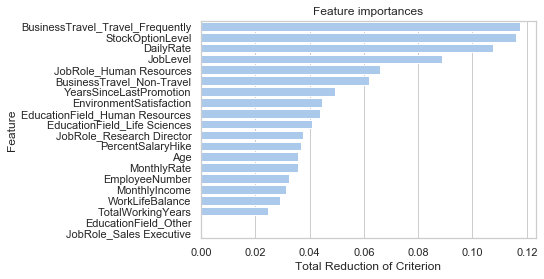

In [167]:
# visualize x-vars by importance
importances = model.feature_importances_  # extract importance metrics 
indices = np.argsort(importances)[::-1] # sorts the rows 

print("Feature ranking:")

feature_names = X.columns 

# create a dataframe using Pandas for the vars using pd.DataFrame() using feature names and importance metrics
fi = pd.DataFrame([feature_names[indices[0:20]], importances[indices][0:20]])
fi = fi.T
fi.columns = ['Feature', 'Total Reduction of Criterion']

print(fi)

# Plot the feature importances of the forest using seaborn
plt.figure()
plt.title("Feature importances")

sns.set_color_codes("pastel")
sns.barplot(x="Total Reduction of Criterion", y="Feature", data=fi, color="b")


## Predictions and Evaluation of Decision Tree

In [168]:
# use predict function to make predictions 
y_pred = model.predict(X_test)

In [171]:
# calculate the confusion matrix for the test data 
confusion_matrix_results = confusion_matrix(y_test, y_pred)

# print the counts of the confusion matrix 
print('confusion matrix: \n', confusion_matrix_results)

# print the metrics 
display_metrics('Decision Tree', y_pred, y_test)


confusion matrix: 
 [[339  31]
 [ 58  13]]
______________________________________________
Model: Decision Tree
Accuracy: 0.7981859410430839
Precision: 0.29545454545454547
Recall: 0.18309859154929578
F1-score: 0.22608695652173913
AUC: 0.549657403882756
______________________________________________



In [170]:
# predict each instance's probability of survival for each individual using 'predict_proba' function
model.predict_proba(X_train)


array([[1.        , 0.        ],
       [1.        , 0.        ],
       [0.89368771, 0.10631229],
       ...,
       [0.89368771, 0.10631229],
       [0.98958333, 0.01041667],
       [0.68292683, 0.31707317]])

# Standardization + PCA

In [476]:
dfs.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [477]:
dfs


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,4,1,6,3,3,2,2,2,2
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,3,0,8,2,2,7,7,3,6
6,59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,4,1,3,12,3,2,1,0,0,0
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,4,2,1,1,2,3,1,0,0,0
8,38,0,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,4,2,0,10,2,3,9,7,1,8
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,3,2,2,17,3,2,7,7,7,7


In [443]:
dfs

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,4,1,6,3,3,2,2,2,2
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,3,0,8,2,2,7,7,3,6
6,59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,4,1,3,12,3,2,1,0,0,0
7,30,0,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,4,2,1,1,2,3,1,0,0,0
8,38,0,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,4,2,0,10,2,3,9,7,1,8
9,36,0,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,3,2,2,17,3,2,7,7,7,7


In [478]:
# create dummy variables for each country using function pd.get_dummies() for variable 'Country'
# add a prefix to names of dummies using 'prefix='Country'
# embed pd.get_dummies(ad_data2['Country'], prefix='Country') inside pd.conat()

# another way:
# countries = pd.get_dummies(ad_data2['Country'], prefix='Country')
# ad_data2 = pd.concat([ad_data2, countries],axis=1)

##-----BusinessTravel------###
dfs = pd.concat([dfs, pd.get_dummies(dfs['BusinessTravel'], prefix='BusinessTravel')],axis=1)
##-----Department------###
dfs = pd.concat([dfs, pd.get_dummies(dfs['Department'], prefix='Department')],axis=1)
##-----EducationField------###
dfs = pd.concat([dfs, pd.get_dummies(dfs['EducationField'], prefix='EducationField')],axis=1)
##-----JobRole------###
dfs = pd.concat([dfs, pd.get_dummies(dfs['JobRole'], prefix='JobRole')],axis=1)
##-----MaritalStatus------###
dfs = pd.concat([dfs, pd.get_dummies(dfs['MaritalStatus'], prefix='MaritalStatus')],axis=1)



In [479]:
### now drop the original 'country' column (you don't need it anymore)


##-----BusinessTravel------###
dfs.drop(['BusinessTravel'],axis=1, inplace=True)
##-----Department------###
dfs.drop(['Department'],axis=1, inplace=True)

##-----EducationField------###
dfs.drop(['EducationField'],axis=1, inplace=True)

##-----JobRole------###
dfs.drop(['JobRole'],axis=1, inplace=True)

##-----MaritalStatus------###
dfs.drop(['MaritalStatus'],axis=1, inplace=True)


In [480]:
dfs.columns()


TypeError: 'Index' object is not callable

In [130]:
# # create the dataset with labels (y-variable, the written number in this case) and features (64 x-variables)
# # label: digit
# # 64 pixels -> 64 x-variables (each var is a pixel, and the value represents the darkness)
# features = pd.DataFrame(df1.data)
# labels = pd.DataFrame(df1.target, columns={'label'}) # label is the value of the target var
# data = pd.concat([labels, features], axis=1)
# data


In [481]:
# Create a list of predictor (x) variables: just Age
predictors1 = ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
               'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Healthcare Representative', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Research Scientist', 'JobRole_Sales Executive',
       'JobRole_Sales Representative', 'MaritalStatus_Divorced',
       'MaritalStatus_Married', 'MaritalStatus_Single']

# Create another list of predictor variables: Age, Country dummies (without the first country dummy) 
# [i for i in ad_data2.columns if i.startswith('Country')]: chooses all items in ad_data2.columns (var names)
# which start with 'Country'
# [i for i in ad_data2.columns if i.startswith('Country')][1:] -> add all countries but the first one (drop country at index 0)


###########predictors2 = ['Age']+[i for i in df1.columns if i.startswith('BusinessTravel')][1:]+[i for i in df1.columns if i.startswith('Department')][1:]+[i for i in df1.columns if i.startswith('EducationField')][1:]+[i for i in df1.columns if i.startswith('JobRole')][1:]+[i for i in df1.columns if i.startswith('MaritalStatus')][1:]


##-----BusinessTravel------###
##-----Department------###
##-----EducationField------###
##-----JobRole------###
##-----MaritalStatus------###




In [482]:
# create dataframes for X (using Age only) and y variables 
features = dfs[predictors1] # choose predictors1
y = dfs['Attrition'] # choose target var

# see list of X variables 
# X.columns is the list of var names
# [i for i in X.columns]: choose all the items in X.columns (var names in X) in list
print('X variables:\n', [i for i in X.columns])


X variables:
 ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRo

In [483]:
features = preprocessing.scale(features)
features

array([[ 0.4463504 ,  0.74252653, -1.01090934, ..., -0.53487311,
        -0.91892141,  1.45864991],
       [ 1.32236521, -1.2977746 , -0.14714972, ..., -0.53487311,
         1.08823234, -0.68556546],
       [ 0.008343  ,  1.41436324, -0.88751511, ..., -0.53487311,
        -0.91892141,  1.45864991],
       ...,
       [-1.08667552, -1.60518328, -0.64072665, ..., -0.53487311,
         1.08823234, -0.68556546],
       [ 1.32236521,  0.54667746, -0.88751511, ..., -0.53487311,
         1.08823234, -0.68556546],
       [-0.32016256, -0.43256792, -0.14714972, ..., -0.53487311,
         1.08823234, -0.68556546]])

In [484]:
features = pd.DataFrame (features)


In [485]:
features.info
# dfs
# 1470 rows × 52 columns



<bound method DataFrame.info of             0         1         2         3    4         5         6   \
0     0.446350  0.742527 -1.010909 -0.891688  0.0 -1.701283 -0.660531   
1     1.322365 -1.297775 -0.147150 -1.868426  0.0 -1.699621  0.254625   
2     0.008343  1.414363 -0.887515 -0.891688  0.0 -1.696298  1.169781   
3    -0.429664  1.461466 -0.764121  1.061787  0.0 -1.694636  1.169781   
4    -1.086676 -0.524295 -0.887515 -1.868426  0.0 -1.691313 -1.575686   
5    -0.539166  0.502054 -0.887515 -0.891688  0.0 -1.689652  1.169781   
6     2.417384  1.292887 -0.764121  0.085049  0.0 -1.686328  0.254625   
7    -0.758170  1.377177  1.827158 -1.868426  0.0 -1.684667  1.169781   
8     0.117845 -1.453958  1.703764  0.085049  0.0 -1.683005  1.169781   
9    -0.101159  1.230910  2.197341  0.085049  0.0 -1.681343  0.254625   
10   -0.210661  0.016150  0.840004  0.085049  0.0 -1.679682 -1.575686   
11   -0.867672 -1.610141  0.716610 -0.891688  0.0 -1.678020  1.169781   
12   -0.648668 -0.3

In [486]:
features.columns =['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
               'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Healthcare Representative', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Research Scientist', 'JobRole_Sales Executive',
       'JobRole_Sales Representative', 'MaritalStatus_Divorced',
       'MaritalStatus_Married', 'MaritalStatus_Single']
# 1470 rows × 52 columns



In [411]:
dfs

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,0.446350,2.280906,0.742527,-1.010909,-0.891688,0.0,-1.701283,-0.660531,-1.224745,1.383138,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.534873,-0.918921,1.458650
1,1.322365,-0.438422,-1.297775,-0.147150,-1.868426,0.0,-1.699621,0.254625,0.816497,-0.240677,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,-0.534873,1.088232,-0.685565
2,0.008343,2.280906,1.414363,-0.887515,-0.891688,0.0,-1.696298,1.169781,0.816497,1.284725,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,-0.918921,1.458650
3,-0.429664,-0.438422,1.461466,-0.764121,1.061787,0.0,-1.694636,1.169781,-1.224745,-0.486709,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,-0.534873,1.088232,-0.685565
4,-1.086676,-0.438422,-0.524295,-0.887515,-1.868426,0.0,-1.691313,-1.575686,0.816497,-1.274014,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565
5,-0.539166,-0.438422,0.502054,-0.887515,-0.891688,0.0,-1.689652,1.169781,0.816497,0.645041,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,-0.918921,1.458650
6,2.417384,-0.438422,1.292887,-0.764121,0.085049,0.0,-1.686328,0.254625,-1.224745,0.743454,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565
7,-0.758170,-0.438422,1.377177,1.827158,-1.868426,0.0,-1.684667,1.169781,0.816497,0.054562,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.869602,-0.918921,-0.685565
8,0.117845,-0.438422,-1.453958,1.703764,0.085049,0.0,-1.683005,1.169781,0.816497,-1.077188,...,-0.462464,-0.273059,3.022901,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,-0.918921,1.458650
9,-0.101159,-0.438422,1.230910,2.197341,0.085049,0.0,-1.681343,0.254625,0.816497,1.383138,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565


In [487]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 51 columns):
Age                                  1470 non-null float64
DailyRate                            1470 non-null float64
DistanceFromHome                     1470 non-null float64
Education                            1470 non-null float64
EmployeeCount                        1470 non-null float64
EmployeeNumber                       1470 non-null float64
EnvironmentSatisfaction              1470 non-null float64
Gender                               1470 non-null float64
HourlyRate                           1470 non-null float64
JobInvolvement                       1470 non-null float64
JobLevel                             1470 non-null float64
JobSatisfaction                      1470 non-null float64
MonthlyIncome                        1470 non-null float64
MonthlyRate                          1470 non-null float64
NumCompaniesWorked                   1470 non-null float64
OverTime

In [488]:
labels = pd.DataFrame(y) # label is the value of the target var

In [489]:
data = pd.concat([labels, features], axis=1)
data

# [1470 rows × 52 columns]



,Attrition,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,1,0.446350,0.742527,-1.010909,-0.891688,0.0,-1.701283,-0.660531,-1.224745,1.383138,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.534873,-0.918921,1.458650
1,0,1.322365,-1.297775,-0.147150,-1.868426,0.0,-1.699621,0.254625,0.816497,-0.240677,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,-0.534873,1.088232,-0.685565
2,1,0.008343,1.414363,-0.887515,-0.891688,0.0,-1.696298,1.169781,0.816497,1.284725,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,-0.918921,1.458650
3,0,-0.429664,1.461466,-0.764121,1.061787,0.0,-1.694636,1.169781,-1.224745,-0.486709,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,-0.534873,1.088232,-0.685565
4,0,-1.086676,-0.524295,-0.887515,-1.868426,0.0,-1.691313,-1.575686,0.816497,-1.274014,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565
5,0,-0.539166,0.502054,-0.887515,-0.891688,0.0,-1.689652,1.169781,0.816497,0.645041,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,-0.918921,1.458650
6,0,2.417384,1.292887,-0.764121,0.085049,0.0,-1.686328,0.254625,-1.224745,0.743454,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565
7,0,-0.758170,1.377177,1.827158,-1.868426,0.0,-1.684667,1.169781,0.816497,0.054562,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.869602,-0.918921,-0.685565
8,0,0.117845,-1.453958,1.703764,0.085049,0.0,-1.683005,1.169781,0.816497,-1.077188,...,-0.462464,-0.273059,3.022901,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,-0.918921,1.458650
9,0,-0.101159,1.230910,2.197341,0.085049,0.0,-1.681343,0.254625,0.816497,1.383138,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565


# PCA

## PCA: Get cumulative explained variance for a particular number of components


In [490]:
# extract x and y vars 
X = data.iloc[:,1:] # all rows, columns 1 and onwards
y = data.iloc[:,0] # all rows, column 0

# define and fit PCA, set n_components (e.g. 10)
pca = PCA(n_components = 10, random_state = 101).fit(X) 

# pca.explained_variance_ratio_ gives var explained by each PC
# use np.sum() to add it up to get cumulative var explained
np.sum(pca.explained_variance_ratio_)


0.4727689464491266

## PCA: Choose the number of components


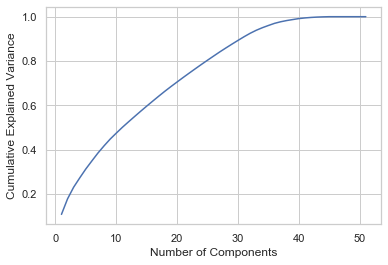

In [491]:
# extract x and y vars 
X = data.iloc[:,1:] # all rows, columns 1 and onwards
y = data.iloc[:,0] # all rows, column 0

# if n_components is not set, then PCA will run for every possible # of components (1 to 64 here)
pca = PCA(random_state = 101).fit(X) 

components = list(range(1, X.shape[1]+1)) # get a list of # of components
cumulative_var = np.cumsum(pca.explained_variance_ratio_) # use np.cumsum function to calculate cumulative var by # of components

plt.plot(components, cumulative_var)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance');


## PCA: Reduce dimensionality and calculate new values based on principal components


In [492]:
# extract x and y vars 
X = data.iloc[:,1:] # all rows, columns 1 and onwards
y = data.iloc[:,0] # all rows, column 0

pca = PCA(n_components = 10, random_state = 101) # choose # of principal components (e.g. 2)

# fit PCA to data 
pca.fit(X) 

# transform x-vars using PCs -> reduce 64 x-vars to 2 
projected = pca.transform(X) 

# format the results into a dataframe
projected_variables = pd.DataFrame(projected)
data2 = pd.concat([labels, projected_variables], axis=1)
data2.head()


,Attrition,0,1,2,3,4,5,6,7,8,9
0,1,-0.068710,2.214302,-1.006357,1.137934,-2.070861,0.236738,-0.441608,-1.985890,0.729441,1.123952
1,0,0.093506,-1.553020,-0.469790,0.304161,2.798424,0.739474,2.642229,-1.379478,-0.801356,-0.278242
2,1,-2.875717,-1.028099,-0.375582,1.108577,-2.125002,-0.337166,0.033076,0.524608,0.324267,-0.485266
3,0,-1.228996,-1.140682,-0.493564,0.538009,1.303493,0.864585,-1.195975,-1.823143,-1.747650,1.075003
4,0,-2.079473,-1.197140,0.279570,-1.078286,-1.106848,-0.444034,-0.666639,1.656853,-1.055548,-1.044047


In [493]:
print(data.iloc[:,1:].shape)
print(data2.iloc[:,1:].shape) 

(1470, 51)
(1470, 10)


## Make predictions with PCA components

components: 1 , accuracy: 0.8367346938775511
components: 2 , accuracy: 0.8253968253968254
components: 3 , accuracy: 0.8095238095238095
components: 4 , accuracy: 0.8276643990929705
components: 5 , accuracy: 0.8390022675736961
components: 6 , accuracy: 0.8117913832199547
components: 7 , accuracy: 0.8367346938775511
components: 8 , accuracy: 0.8344671201814059
components: 9 , accuracy: 0.8367346938775511
components: 10 , accuracy: 0.8299319727891157
components: 11 , accuracy: 0.8208616780045351
components: 12 , accuracy: 0.8321995464852607
components: 13 , accuracy: 0.8344671201814059
components: 14 , accuracy: 0.8299319727891157
components: 15 , accuracy: 0.8299319727891157
components: 16 , accuracy: 0.8231292517006803
components: 17 , accuracy: 0.8390022675736961
components: 18 , accuracy: 0.8367346938775511
components: 19 , accuracy: 0.7959183673469388
components: 20 , accuracy: 0.81859410430839
components: 21 , accuracy: 0.8367346938775511
components: 22 , accuracy: 0.8027210884353742

Text(0.5, 1.0, 'Accuracy vs. # of Principal Components')

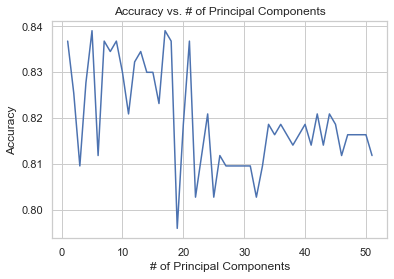

In [494]:
X = data.iloc[:,1:]
y = data.iloc[:,0]

accuracies = [] # compare accuracies for using diff # of components
components = list(range(1, X.shape[1]+1)) # a list of 1 to 64 

for i in range(1, X.shape[1]+1): # loop through 1 to 64 
    
    # define PCA
    pca = PCA(n_components = i, random_state = 101) 
    
    # fit PCA to data
    pca.fit(X)
    
    # transform x-vars using PCs -> reduce 64 x-vars to i x-vars
    projected = pca.transform(X)
    projected_variables = pd.DataFrame(projected)
    
    # new data with dimensionality reduction
    data2 = pd.concat([labels, projected_variables], axis=1)
    
    # extract new x-vars after dimensionality reduction
    X2 = data2.iloc[:,1:]
    y2 = data2.iloc[:,0]
    
    # split data into train/test data
    X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.3, random_state = 101, stratify=y2)
    
    # DT Model
    model =  DecisionTreeClassifier(criterion='entropy', random_state=101, max_depth=5)

    # fit the model
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)
    
    print('components:', i, ', accuracy:', acc)

plt.plot(components, accuracies)
plt.ylabel('Accuracy')
plt.xlabel('# of Principal Components')
plt.title('Accuracy vs. # of Principal Components')

# components: 5 , accuracy: 0.8390022675736961
# components: 17 , accuracy: 0.8390022675736961



In [144]:
# # print(X_train)
# y_train
# y_train = pd.DataFrame(y_train)
# print(y_train)
# isinstance(y_train, pd.DataFrame)


In [145]:
# le = LabelEncoder()

# le.fit(y_train)

# y_train = le.transform(y_train)
# y_test = le.transform(y_test)

# y_train
# y

In [146]:
# y_train['Attrition'].value_counts()

# # y_train.value_counts



## Training a Decision Tree Model
- Use DecisionTreeClassifier in sklearn 
- Some paramters: 
    - criterion: The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “entropy” for the information gain.
    - max_depth: The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
    - min_samples_leaf: The minimum number of samples required to be at a leaf node. 
    - max_features: The number of features to consider when looking for the best split:
    - see all parameters in the documentation: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

## Data Prep: Decision Tree

### 1. Unbalanced DV

In [147]:
# y_train



In [148]:

# print('Original dataset shape %s' % Counter(y))
# ada = ADASYN(random_state=101)
# X_res, y_res = ada.fit_resample(X, y)
# # print('Resampled dataset shape %s' % Counter(y_res))




# # # summarize class distribution
# # counter = Counter(y)
# # print(counter)
# # # transform the dataset
# # sm = ADASYN(random_state=101)
# # X_res, y_res = sm.fit_resample(X_train, y_train)
# # # summarize the new class distribution
# # counter = Counter(y_res)
# # print(counter)
# # # scatter plot of examples by class label
# # for label, _ in counter.items():
# # 	row_ix = where(y_res == label)[0]
# # 	pyplot.scatter(X_res[row_ix, 0], X_res[row_ix, 1], label=str(label))
# # pyplot.legend()
# # pyplot.show()




# # def makeOverSamplesADASYN(X,y):
# #  #input DataFrame
# #  #X →Independent Variable in DataFrame\
# #  #y →dependent Variable in Pandas DataFrame format
# #  from imblearn.over_sampling import ADASYN 
# #  sm = ADASYN()
# #  X, y = sm.fit_sample(X, y)
# #  return(X,y)



# # #Apply Over Sampling
# # print('Before Oversampling')
# # print(sorted(Counter(y_train).items()))
# # X_train, y_train = SMOTE().fit_resample(X_train, y_train)
# # print('After Oversampling')
# # print(sorted(Counter(y_train).items()))
# # #Standard Scaler
# # #scaler = StandardScaler()  
# # #scaler.fit(X_train)  
# # #X_train = scaler.transform(X_train)  
# # #X_test = scaler.transform(X_test)  

In [149]:
# # train model, set criterion, max_depth=5 (no tree over 5 levels)
# model_dt = DecisionTreeClassifier(criterion='entropy', random_state=101, max_depth=5)
# a
# # fit the model
# model_dt.fit(X_train, y_train)


## Feature Importance


Feature ranking:
                             Feature Total Reduction of Criterion
0                                Age                     0.225553
1         Department_Human Resources                     0.148106
2                   StockOptionLevel                    0.0978562
3                          Education                    0.0634495
4          JobRole_Research Director                    0.0621853
5                 NumCompaniesWorked                    0.0605194
6     JobRole_Manufacturing Director                    0.0566266
7  Department_Research & Development                     0.040951
8                   DistanceFromHome                     0.038391
9           EducationField_Marketing                    0.0355143


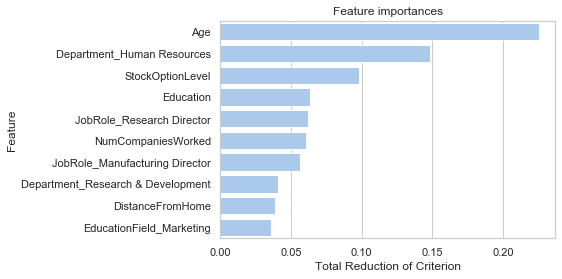

In [497]:
# visualize x-vars by importance
importances = model.feature_importances_  # extract importance metrics 
indices = np.argsort(importances)[::-1] # sorts the rows 

print("Feature ranking:")

feature_names = X.columns 

# create a dataframe using Pandas for the vars using pd.DataFrame() using feature names and importance metrics
fi = pd.DataFrame([feature_names[indices[0:10]], importances[indices][0:10]])
fi = fi.T
fi.columns = ['Feature', 'Total Reduction of Criterion']

print(fi)

# Plot the feature importances of the forest using seaborn
plt.figure()
plt.title("Feature importances")

sns.set_color_codes("pastel")
sns.barplot(x="Total Reduction of Criterion", y="Feature", data=fi, color="b")


## Predictions and Evaluation of Decision Tree

In [498]:
# use predict function to make predictions 
y_pred = model.predict(X_test)

In [499]:
# calculate the confusion matrix for the test data 
confusion_matrix_results = confusion_matrix(y_test, y_pred)

# print the counts of the confusion matrix 
print('confusion matrix: \n', confusion_matrix_results)

# print the metrics 
display_metrics('Decision Tree', y_pred, y_test)


confusion matrix: 
 [[345  25]
 [ 58  13]]
______________________________________________
Model: Decision Tree
Accuracy: 0.8117913832199547
Precision: 0.34210526315789475
Recall: 0.18309859154929578
F1-score: 0.23853211009174313
AUC: 0.5577655119908641
______________________________________________

